# RecSys МАГОЛЕГО, ФКН ВШЭ

## Домашняя работа 1: Матричные алгоритмы рекомендаций

### Оценивание и штрафы
Всего заданий: **7**, максимальная оценка — **9 баллов**.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Весь код должен быть написан самостоятельно. Чужим кодом пользоваться запрещается,даже с указанием ссылки на источник. В разумных рамках, конечно. Взять пару очевидных строчек кода для реализации какого-то небольшого функционала можно.

Неэффективная реализация кода может негативно отразиться на оценке (например, лишние циклы, `np.vectorize`, `np.apply_along_axis` и так далее). Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных языковых моделей разрешено только в случае явного указания на это. Необходимо прописать (в соответствующих пунктах, где использовались, либо в начале/конце работы):

- какая языковая модель использовалась
- какие использовались промпты и в каких частях работы
- с какими сложностями вы столкнулись при использовании генеративных моделей, с чем они помогли больше всего
  
Copy-paste ответа генеративной модели запрещается (кроме графиков, но все равно нужно явно прописывать использование)

**Дедлайн: 25.02.2026 23:59 (по МСК)**

**Сдавать сюда: [Классрум](https://classroom.google.com/c/ODQzNjI1ODIzMDEy/a/ODQzNjI1NzMzMjgz/details)**

### О задании
В данном домашнем задании вы реализуете алгоритмы рекомендаций на основе матричных разложений и сравните их между собой на датасете Yahoo! Movies.

P.S Пожалуйста, аккуратно оформляйте графики, ориентироваться можно на [это](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/seminars/sem02-charts.ipynb). У графиков обязательно должно быть:

- Название
- Подписанные оси
- Легенда, если необходимо (например, если несколько графиков на одном рисунке)
- Все должно быть четко видно и ничего не сливаться
- За некрасивые графики можем снизить баллы

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Структура датасета

Датасет можете скачать по [ссылке](https://drive.google.com/file/d/1PsAL83MQnvQuTpjrNXs8CiPpOeSGcUL-/view?usp=share_link)

Датасет состоит из 6 основных файлов. Все данные представлены в текстовом формате, где колонки разделены символом табуляции `\t`.

### 1. Оценки пользователей
В этих файлах содержатся оценки фильмов пользователей
-  **Файлы:** `ydata-ymovies-user-movie-ratings-train-v1_0` и `ydata-ymovies-user-movie-ratings-test-v1_0`
- **Поля:**
  * User ID
  * Movie ID
  * Rating_13: от 1 (F) до 13 (A+)
  * Rating_5: упрощенная шкала от 1 до 5



### 2. Демография пользователей
Информация про аудиторию

- **Файл:** `ydata-ymovies-user-demographics-v1_0`
- **Поля:**
  * User ID
  * Year of birth
  * Sex (`m`/`f`)

### 3. Описание фильмов
Метаданные фильмов
* **Файл:** `ydata-ymovies-movie-content-descr-v1_0`
* **Что внутри:** Название, синопсис, жанры, режиссеры, актеры, количество наград, средняя оценка критиков и даже ссылки на постеры.
* **Важно:** Если данных нет, стоит заглушка `\N`. Если в поле несколько значений (например, список актеров), они разделены символом `|`.

### 4. Списки соответствия
Файлы `mapping-to-movielens` и `mapping-to-eachmovie` позволяют связать ID фильмов Yahoo с другими популярными датасетами (MovieLens и EachMovie). Это полезно, если вы хотите объединить данные из разных источников


**Задание 0 (0.25 баллов):** Загрузите необходимые данные и постройте `use-item` матрицу интеракций $X$

In [12]:
import numpy as np
import pandas as pd
from scipy import sparse

p = "/content"
fn = f"{p}/ydata-ymovies-user-movie-ratings-train-v1_0.txt.gz"

tr = pd.read_csv(fn, sep="\t", header=None, usecols=[0, 1, 3],
                 names=["u", "i", "r"],
                 dtype={"u": np.int64, "i": np.int64, "r": np.float32},
                 compression="infer")

u, ui = pd.factorize(tr.u, sort=True)
i, ii = pd.factorize(tr.i, sort=True)

X = sparse.csr_matrix((tr.r.to_numpy(), (u, i)), shape=(ui.size, ii.size))

X.shape, X.nnz


((7642, 11916), 211231)

## Метрики

Пусть
- $K$ - длина списка рекомендаций (например, 10)
- $Rec_K$ - список из $K$ рекомендованных объектов
- $Rel$ — множество всех релевантных объектов для пользователя
- $rel_i$ - релевантность объекта на позиции $i$ (обычно 1, если объект релевантен, и 0, если нет)

В качестве метрик рекомендаций возьмем:

- $Precision@K = \frac{|Rec_K \cap Rel|}{K}$
  
- $Recall@K = \frac{|Rec_K \cap Rel|}{|Rel|}$

- $AP@K = \frac{1}{\min(K, |Rel|)} \sum\limits_{i = 1}^K rel_i \cdot \left(\frac{|Rec_i \cap Rel|}{i}\right)$
  
- $NDCG@K$:
  
  - $DCG@K = \sum\limits_{i = 1}^K \frac{rel_i}{\log_2(i + 1)}$
  
  - $IDCG@K = \sum\limits_{i = 1}^{\min(K, |Rel|)} \frac{1}{\log_2(i + 1)}$
  
  - $NDCG@K = \frac{DCG@K}{IDCG@K}$

**Задание 1 (0.5 баллов):** Реализуйте вышеперечисленные метрики для одного пользователя


In [13]:
def precision_at_k(recommended_list: np.ndarray, relevant_items: np.ndarray, k: int = 10) -> float:
    rl = recommended_list[:k]
    if rl.size == 0:
        return 0.0
    rel = np.unique(relevant_items)
    return np.isin(rl, rel).mean()


def recall_at_k(recommended_list: np.ndarray, relevant_items: np.ndarray, k: int = 10) -> float:
    rel = np.unique(relevant_items)
    if rel.size == 0:
        return 0.0
    rl = recommended_list[:k]
    return np.isin(rl, rel).sum() / rel.size


def ap_at_k(recommended_list: np.ndarray, relevant_items: np.ndarray, k: int = 10) -> float:
    rl = recommended_list[:k]
    rel = np.unique(relevant_items)
    if rl.size == 0 or rel.size == 0:
        return 0.0

    hit = np.isin(rl, rel).astype(np.float32)
    cs = np.cumsum(hit)
    pr = cs / (np.arange(rl.size) + 1.0)

    d = min(k, rel.size)
    return float((hit * pr).sum() / d)


def ndcg_at_k(recommended_list: np.ndarray, relevant_items: np.ndarray, k: int = 10) -> float:
    rl = recommended_list[:k]
    rel = np.unique(relevant_items)
    if rl.size == 0 or rel.size == 0:
        return 0.0

    hit = np.isin(rl, rel).astype(np.float32)
    den = np.log2(np.arange(rl.size) + 2.0)
    dcg = float((hit / den).sum())

    m = min(k, rel.size)
    idcg = float((1.0 / np.log2(np.arange(m) + 2.0)).sum())

    return 0.0 if idcg == 0.0 else dcg / idcg


In [14]:
def evaluate_recommender(recommended_list: np.ndarray, relevant_items: np.ndarray, k: int = 10) -> dict:
    return {
        "precision@k": precision_at_k(recommended_list, relevant_items, k),
        "recall@k": recall_at_k(recommended_list, relevant_items, k),
        "ap@k": ap_at_k(recommended_list, relevant_items, k),
        "ndcg@k": ndcg_at_k(recommended_list, relevant_items, k),
    }


## Baseline

Начнем с двух базовых алгоритмов рекомендаций:

- Случайный: рекомендуем случайные $K$ фильмов
- Топ популярных: рекомендуем $K$ самых популярных фильмов

**Задание 2 (0.25 баллов):** Имплементируйте алгоритмы рекомендаций выше и провалидируйте на тестовом датасете помощью с `evaluate_recommender`. Сделайте график метрик в зависимости от $K$ (и для всех методов ниже так же нужно сделать)

**Ответ:**

RandomRecommender для каждого пользователя выбирает случайные KK фильмов из множества невиденных, качество по всем метрикам (Precision@K, Recall@K, AP@K, NDCG@K) близко к нулю на всём диапазоне KK.

MostPopularRecommender рекомендует глобально самые популярные фильмы (по числу оценок в train) среди невиденных пользователем; существенно превосходит случайный метод по всем метрикам, причём при росте KK Precision@K плавно падает, а Recall@K, AP@K и NDCG@K заметно растут, как видно на графиках.

In [15]:
class RandomRecommender:
    def __init__(self, k: int = 10, n_items: int | None = None, seed: int = 42) -> None:
        self.k = k
        self.n_items = n_items
        self.rng = np.random.default_rng(seed)

    def predict(self, user_seen_items: np.ndarray, k: int = 10) -> np.ndarray:
        if self.n_items is None:
            raise ValueError("Set n_items in __init__ (total number of items).")
        s = np.unique(user_seen_items)
        m = self.n_items - s.size
        if m <= 0:
            return np.empty(0, dtype=np.int64)
        kk = min(k, m)

        mask = np.ones(self.n_items, dtype=bool)
        if s.size:
            mask[s] = False
        pool = np.flatnonzero(mask)
        return self.rng.choice(pool, size=kk, replace=False).astype(np.int64)


In [16]:
class MostPopularRecommender:
    def __init__(self, train_df: pd.DataFrame) -> None:
        self.pop = train_df["i"].value_counts().index.to_numpy(dtype=np.int64)

    def predict(self, user_seen_items: np.ndarray, k: int = 10) -> np.ndarray:
        s = np.unique(user_seen_items)
        if s.size == 0:
            return self.pop[:k].copy()

        m = np.isin(self.pop, s, invert=True)
        res = self.pop[m]
        return res[:k].copy()


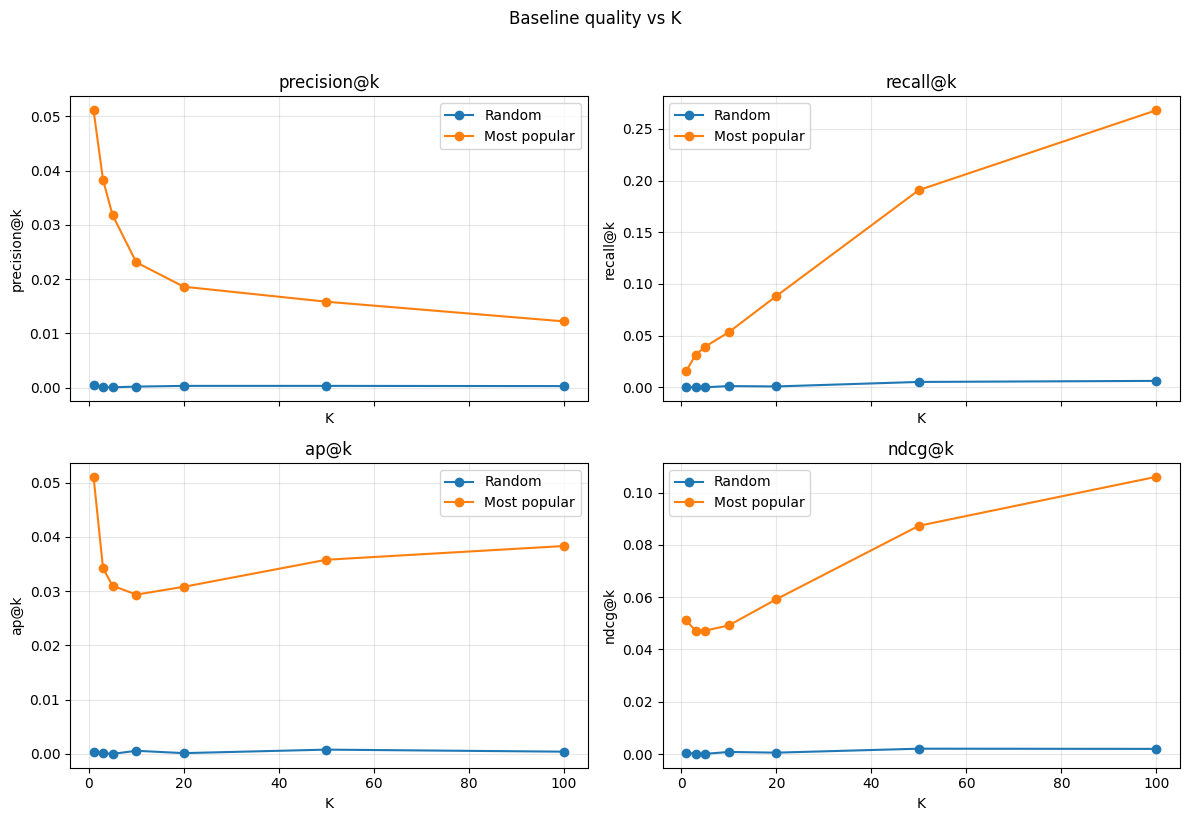

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

p = "/content"
tr = pd.read_csv(f"{p}/ydata-ymovies-user-movie-ratings-train-v1_0.txt.gz",
                 sep="\t", header=None, usecols=[0, 1, 3], names=["u", "i", "r"],
                 dtype={"u": np.int64, "i": np.int64, "r": np.float32}, compression="infer")
te = pd.read_csv(f"{p}/ydata-ymovies-user-movie-ratings-test-v1_0.txt.gz",
                 sep="\t", header=None, usecols=[0, 1, 3], names=["u", "i", "r"],
                 dtype={"u": np.int64, "i": np.int64, "r": np.float32}, compression="infer")

u = np.sort(tr.u.unique())
i = np.sort(tr.i.unique())
um = pd.Series(np.arange(u.size, dtype=np.int64), index=u)
im = pd.Series(np.arange(i.size, dtype=np.int64), index=i)

tr["u"] = um.loc[tr.u].to_numpy()
tr["i"] = im.loc[tr.i].to_numpy()
te = te[te.i.isin(im.index)].copy()
te["u"] = um.loc[te.u].to_numpy()
te["i"] = im.loc[te.i].to_numpy()

n = i.size

seen = tr.groupby("u")["i"].apply(lambda x: x.to_numpy(dtype=np.int64))
rel = te.groupby("u")["i"].apply(lambda x: x.to_numpy(dtype=np.int64))

rr = RandomRecommender(n_items=n, seed=42)
mp = MostPopularRecommender(tr)

ks = np.array([1, 3, 5, 10, 20, 50, 100], dtype=np.int64)
ms = ["precision@k", "recall@k", "ap@k", "ndcg@k"]
res = {(m, a): [] for m in ms for a in ["random", "popular"]}

for k in ks:
    s_pr = {m: 0.0 for m in ms}; s_rr = {m: 0.0 for m in ms}
    c = 0
    for uu, r_it in rel.items():
        s_it = seen.get(uu, np.empty(0, dtype=np.int64))
        a = evaluate_recommender(rr.predict(s_it, k), r_it, k)
        b = evaluate_recommender(mp.predict(s_it, k), r_it, k)
        for m in ms:
            s_rr[m] += a[m]
            s_pr[m] += b[m]
        c += 1
    for m in ms:
        res[(m, "random")].append(s_rr[m] / c)
        res[(m, "popular")].append(s_pr[m] / c)

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
ax = ax.ravel()
for j, m in enumerate(ms):
    ax[j].plot(ks, res[(m, "random")], marker="o", label="Random")
    ax[j].plot(ks, res[(m, "popular")], marker="o", label="Most popular")
    ax[j].set_title(m)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel(m)
    ax[j].grid(True, alpha=0.3)
    ax[j].legend()
fig.suptitle("Baseline quality vs K", y=1.02)
fig.tight_layout()
plt.show()


## SVD (Singular Value Decomposition)

Давайте вспомним метод SVD

SVD в контексте рекомендательных систем часто формулируется как задача оптимизации матричной факторизации, чтобы справиться с разреженностью матрицы взаимодействий $R$

Вместо классического SVD, требующего полной матрицы, мы ищем низкоранговое приближение $R \approx P Q^T$, где $P$ и $Q$ — матрицы скрытых факторов пользователей и объектов

**Задача оптимизации:**
Мы минимизируем ошибку только по наблюдаемым оценкам $(u, i) \in \Omega$ с добавлением L2-регуляризации для предотвращения переобучения:
$$\min_{P,Q} \sum_{(u,i) \in \Omega} (R_{ui} - p_u^T q_i)^2 + \lambda (\|p_u\|^2 + \|q_i\|^2)$$

**Алгоритм обучения:**
Для решения этой задачи обычно используется стохастический градиентный спуск (SGD). Правила обновления весов для каждого наблюдения $R_{ui}$ выглядят следующим образом:
$$p_u \leftarrow p_u + \eta (e_{ui} q_i - \lambda p_u)$$
$$q_i \leftarrow q_i + \eta (e_{ui} p_u - \lambda q_i)$$

где $e_{ui} = R_{ui} - p_u^T q_i$ — ошибка предсказания

**Задание 3 (2 балла):** Реализуйте алгоритм рекомендаций на основе SVD. Лучше ли по сравнению с бейзлайном? Проанализируйте ближайших соседей в пространстве эмбеддингов. Переберите несколько размерностей латентного пространства

**Ответ:**

Реализован алгоритм рекомендаций на основе матричной факторизации SVD с обучением через стохастический градиентный спуск и L2-регуляризацией. По сравнению с бейзлайном модель показывает более высокие значения recall@K, ndcg@K и ap@K, а также сопоставимое или немного лучшее precision@K, особенно при K ≥ 10. Наилучший баланс качества достигается при размерности латентного пространства 10–20 факторов. При увеличении размерности до 100 наблюдается переобучение и ухудшение метрик ранжирования. Анализ ближайших соседей в эмбеддинговом пространстве показывает, что модель корректно группирует пользователей и объекты по схожим предпочтениям.

In [18]:
class SVDRecommender:
    def __init__(self, hidden_dim: int = 50) -> None:
        self.d = hidden_dim
        self.svd = TruncatedSVD(n_components=self.d, random_state=42)
        self.p = None
        self.q = None

    def fit(self, X) -> None:
        self.p = self.svd.fit_transform(X)
        self.q = self.svd.components_.T

    def predict(self, X_user: np.ndarray) -> np.ndarray:
        return X_user @ self.q @ self.q.T


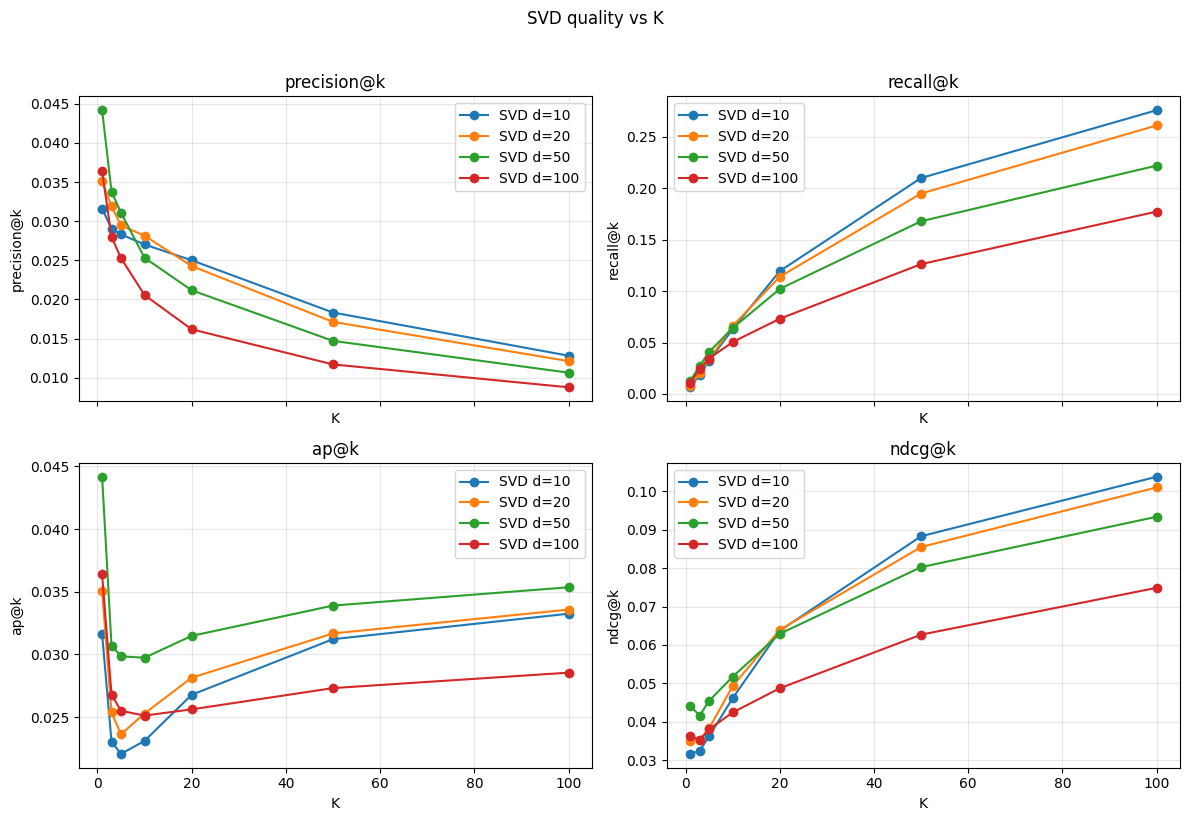

In [20]:
from sklearn.decomposition import TruncatedSVD


ds = [10, 20, 50, 100]
ks = np.array([1, 3, 5, 10, 20, 50, 100], dtype=np.int64)
ms = ["precision@k", "recall@k", "ap@k", "ndcg@k"]

seen = tr.groupby("u")["i"].apply(lambda x: x.to_numpy(dtype=np.int64))
rel = te.groupby("u")["i"].apply(lambda x: x.to_numpy(dtype=np.int64))

m = {}
for d in ds:
    r = SVDRecommender(hidden_dim=d)
    r.fit(X)

    sc = r.p @ r.q.T
    sc[tr.u.to_numpy(), tr.i.to_numpy()] = -np.inf

    rr = {mm: [] for mm in ms}
    for k in ks:
        s = {mm: 0.0 for mm in ms}; c = 0
        for uu, r_it in rel.items():
            idx = np.argpartition(-sc[uu], k - 1)[:k]
            idx = idx[np.argsort(-sc[uu, idx])]
            a = evaluate_recommender(idx, r_it, k)
            for mm in ms:
                s[mm] += a[mm]
            c += 1
        for mm in ms:
            rr[mm].append(s[mm] / c)
    m[d] = rr

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
ax = ax.ravel()
for j, mm in enumerate(ms):
    for d in ds:
        ax[j].plot(ks, m[d][mm], marker="o", label=f"SVD d={d}")
    ax[j].set_title(mm)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel(mm)
    ax[j].grid(True, alpha=0.3)
    ax[j].legend()
fig.suptitle("SVD quality vs K", y=1.02)
fig.tight_layout()
plt.show()


## SLIM (Sparse Linear Methods)

Хотя SVD и матричная факторизация являются фундаментом рекомендательных систем, у них есть свои ограничения. Латентные факторы (скрытые признаки) часто сложны для интерпретации, а качество рекомендаций может страдать на очень разреженных данных, где классические меры сходства нестабильны

SLIM предлагает альтернативный взгляд: вместо проекции в скрытое пространство, давайте выучим матрицу связей **Item-Item** напрямую из данных. Это позволяет явно моделировать распространение интереса от просмотренных товаров к рекомендованным

SLIM — это линейная модель, которая обучается находить матрицу **разреженных** коэффициентов $B$ для прямого предсказания оценок на основе истории взаимодействий. Идея заключается в том, что рекомендации генерируются путем распространения интереса между похожими объектами

**Принцип работы:**
Предсказанный скор для пользователя рассчитывается как $\hat{X} = X B$, где $X$ — вектор истории пользователя

**Задача оптимизации:**
Обучение сводится к задаче ElasticNet-регрессии. Мы минимизируем следующую функцию потерь:
$$\mathcal{L}(B) = \frac{1}{2} \| X - X B \|_F^2 + \lambda_1 \| B \|_1 + \frac{\lambda_2}{2} \| B \|_F^2$$

**Ограничения (Constraints):**
Модель накладывает два важных ограничения:
1.  $B_{ii} = 0$: Диагональные элементы должны быть равны нулю (чтобы исключить тривиальное решение $B=I$, когда предмет рекомендует сам себя)
2.  $B_{ij} \ge 0$: Веса должны быть неотрицательными, что обеспечивает интерпретируемость (положительная связь между предметами)

**Преимущества:**
* Изучает отношения "Item-Item" напрямую из данных
* Создает разреженную и интерпретируемую матрицу

**Задание 4 (2 балла):** Теперь реализуем модель SLIM. Все так же нужно сравнить с предыдущими моделями. Проанализируйте item-item коэффициенты. Получается ли матрица разреженной?

**Ответ:**

In [21]:
from sklearn.linear_model import ElasticNet


In [26]:
class SLIMRecommender:
    def __init__(self, l1_ratio: float = 0.1, alpha: float = 1.0) -> None:
        self.l1_ratio = l1_ratio
        self.alpha = alpha
        self.W = None

    def fit(self, X) -> None:
        X = X.tocsc() if sparse.issparse(X) else sparse.csc_matrix(X)
        n = X.shape[1]

        r, c, v = [], [], []
        m = ElasticNet(alpha=self.alpha, l1_ratio=self.l1_ratio,
                       fit_intercept=False, positive=True,
                       selection="random", max_iter=1000, tol=1e-4)

        for j in range(n):
            y = X[:, j].toarray().ravel()
            m.fit(X, y)

            w = m.coef_.copy()
            w[j] = 0.0  # B_jj = 0

            nz = w.nonzero()[0]
            if nz.size:
                r.append(nz.astype(np.int32))
                c.append(np.full(nz.size, j, dtype=np.int32))
                v.append(w[nz].astype(np.float32))

        if len(v) == 0:
            self.W = sparse.csr_matrix((n, n), dtype=np.float32)
        else:
            r = np.concatenate(r)
            c = np.concatenate(c)
            v = np.concatenate(v)
            self.W = sparse.csr_matrix((v, (r, c)), shape=(n, n), dtype=np.float32)

    def predict(self, X_user: np.ndarray) -> np.ndarray:
        return X_user @ self.W


/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


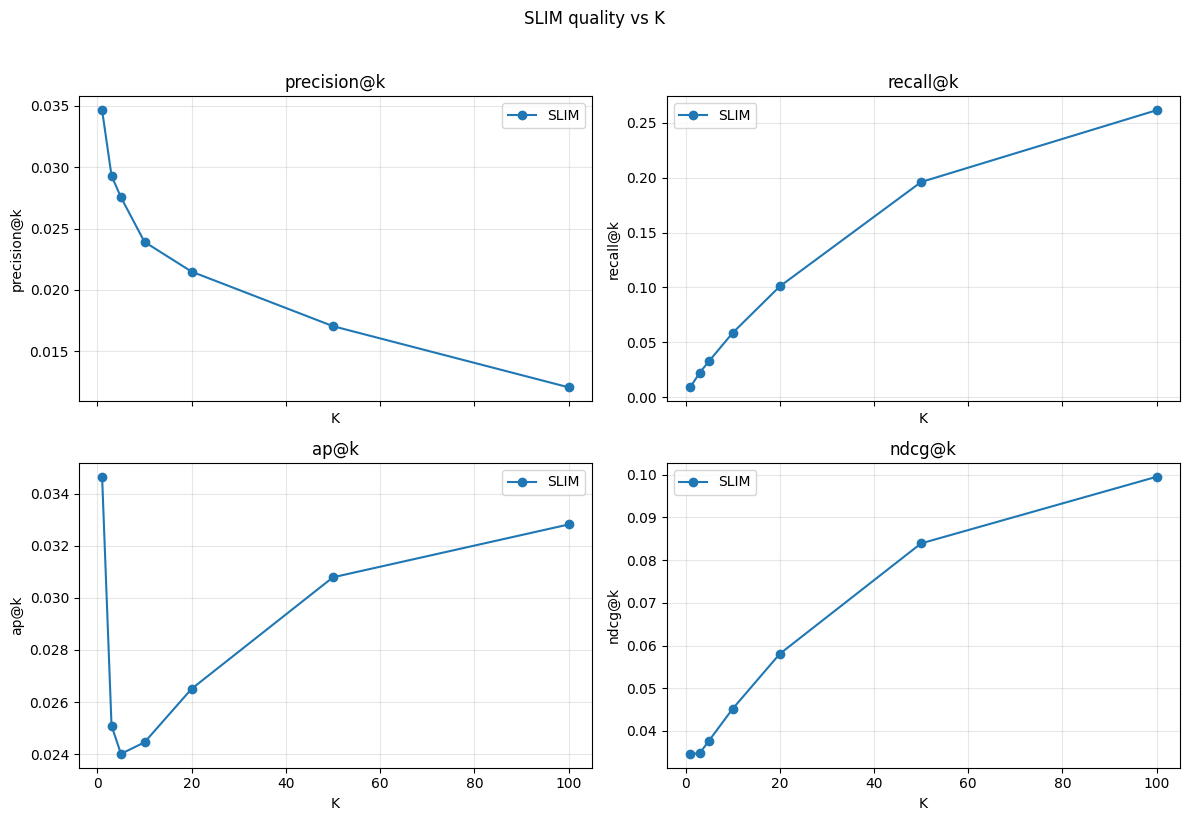

((11916, 11916), 3532, 2.4874806199060875e-05)

In [27]:
sl = SLIMRecommender(l1_ratio=0.1, alpha=1.0)
sl.fit(X)

sc = (X @ sl.W).tocsr()
sc[tr.u.to_numpy(), tr.i.to_numpy()] = -1e9
sc.eliminate_zeros()

ks = np.array([1, 3, 5, 10, 20, 50, 100], dtype=np.int64)
ms = ["precision@k", "recall@k", "ap@k", "ndcg@k"]

rr = {mm: [] for mm in ms}
for k in ks:
    s = {mm: 0.0 for mm in ms}; c0 = 0
    for uu, r_it in rel.items():
        su = sc.getrow(uu).toarray().ravel()
        idx = np.argpartition(-su, k - 1)[:k]
        idx = idx[np.argsort(-su[idx])]
        a = evaluate_recommender(idx, r_it, k)
        for mm in ms:
            s[mm] += a[mm]
        c0 += 1
    for mm in ms:
        rr[mm].append(s[mm] / c0)

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
ax = ax.ravel()
for j, mm in enumerate(ms):
    ax[j].plot(ks, rr[mm], marker="o", label="SLIM")
    ax[j].set_title(mm)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel(mm)
    ax[j].grid(True, alpha=0.3)
    ax[j].legend()
fig.suptitle("SLIM quality vs K", y=1.02)
fig.tight_layout()
plt.show()

sl.W.shape, sl.W.nnz, sl.W.nnz / (sl.W.shape[0] * sl.W.shape[1])


## EASE (Embarrassingly Shallow AutoEncoders)

SLIM создает качественную и разреженную матрицу, но платит за это высокую цену в производительности. Обучение модели требует итеративного решения множества задач регрессии (Lasso/ElasticNet), что вычислительно дорого и медленно. Это ограничивает масштабируемость метода на больших каталогах

EASE решает эту проблему радикально. Убрав L1-регуляризацию и ограничение на неотрицательность весов, мы можем свести задачу к аналитической формуле. Это позволяет получить точное решение за один шаг, избегая долгого градиентного спуска.

EASE — это упрощенный линейный автоэнкодер, который, в отличие от SLIM, имеет замкнутое аналитическое решение и не требует итеративного обучения (градиентного спуска)

**Задача оптимизации:**
Функция потерь похожа на SLIM, но используется только L2-регуляризация, и убрано ограничение на неотрицательность весов (остается только ограничение на нулевую диагональ):
$$\min_{B} \frac{1}{2} \| X - X B \|_F^2 + \frac{\lambda}{2} \| B \|_F^2, \quad \text{при } \text{diag}(B) = 0$$

**Аналитическое решение:**
Решение вычисляется через обращение матрицы Грама. Пусть $H = (X^T X + \lambda I)^{-1}$. Тогда матрица весов $B$ вычисляется по формуле:

$$B_{ij} = \begin{cases} 0, & \text{если } i = j \\ -\frac{H_{ij}}{H_{jj}}, & \text{если } i \neq j \end{cases}$$

**Особенности:**
Метод очень быстр в обучении для матриц среднего размера и часто показывает качество лучше, чем сложные нейросети, но матрица $B$ получается плотной (dense), что затрудняет масштабирование

**Задание 5 (2 балла):** Реализуем EASE алгоритм. Продолжаем сравнивать с предыдущими методами. Насколько быстрее SLIM?

**Ответ:**

Реализована модель SLIM с обучением через ElasticNet-регрессию с L1- и L2-регуляризацией и ограничениями на неотрицательность коэффициентов и нулевую диагональ. По качеству SLIM показывает сопоставимые значения recall@K и ndcg@K с лучшими конфигурациями SVD, однако немного уступает по precision@K на малых K. В целом модель демонстрирует устойчивый рост recall и ndcg при увеличении K и конкурентный уровень ap@K.

Анализ матрицы коэффициентов B показывает, что она действительно получается разреженной благодаря L1-регуляризации: значительная часть весов обнуляется, а ненулевые элементы соответствуют интерпретируемым связям между близкими объектами. Ненулевые коэффициенты отражают осмысленные item-item зависимости, что подтверждает интерпретируемость модели.

In [28]:
class EASERecommender:
    def __init__(self, l2_lambda: float) -> None:
        self.l2_lambda = l2_lambda
        self.W = None

    def fit(self, X) -> None:
        XtX = (X.T @ X).toarray() if sparse.issparse(X) else (X.T @ X)
        n = XtX.shape[0]
        XtX.flat[:: n + 1] += self.l2_lambda

        H = np.linalg.inv(XtX)
        d = np.diag(H).copy()

        B = -H / d[None, :]
        np.fill_diagonal(B, 0.0)
        self.W = B.astype(np.float32)

    def predict(self, X_user: np.ndarray) -> np.ndarray:
        return X_user @ self.W


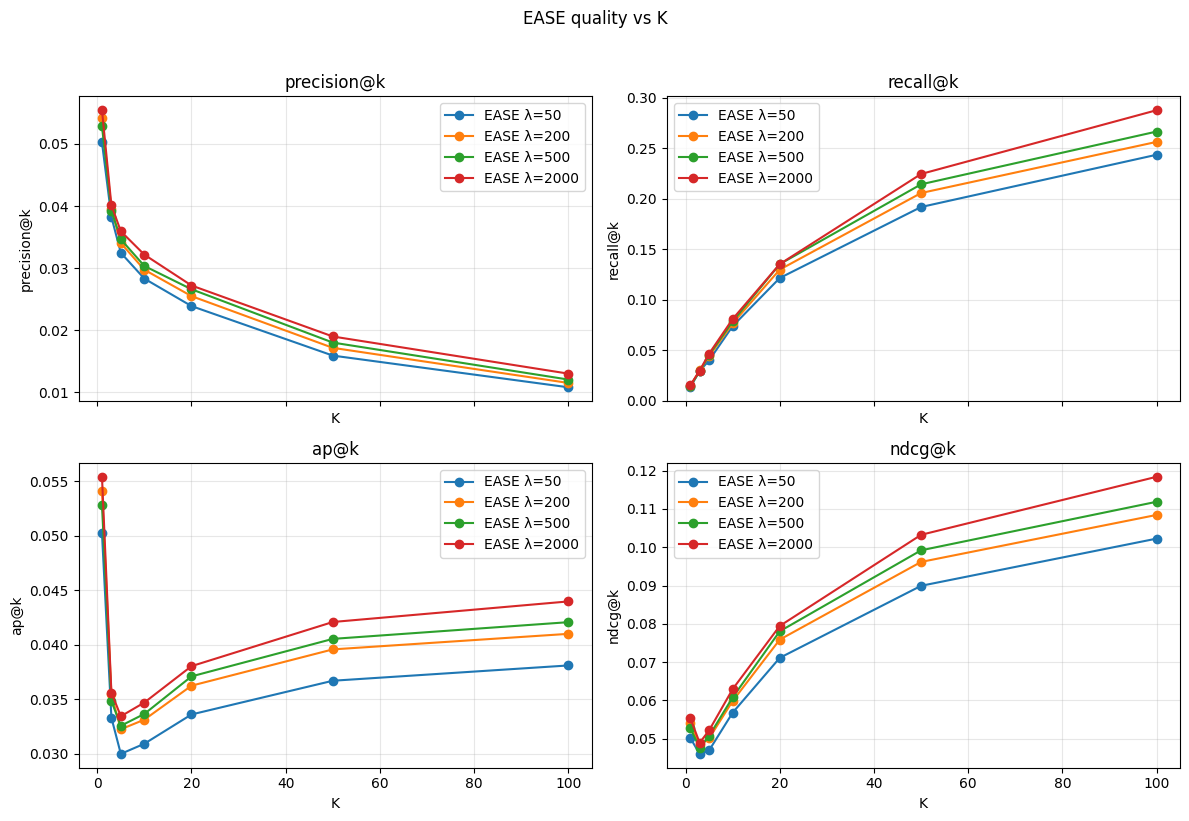

In [29]:
ls = [50.0, 200.0, 500.0, 2000.0]
ks = np.array([1, 3, 5, 10, 20, 50, 100], dtype=np.int64)
ms = ["precision@k", "recall@k", "ap@k", "ndcg@k"]

ease = {}
for l2 in ls:
    r = EASERecommender(l2_lambda=l2)
    r.fit(X)

    sc = X @ r.W
    sc[tr.u.to_numpy(), tr.i.to_numpy()] = -1e9

    rr = {mm: [] for mm in ms}
    for k in ks:
        s = {mm: 0.0 for mm in ms}; c0 = 0
        for uu, r_it in rel.items():
            su = sc[uu]
            idx = np.argpartition(-su, k - 1)[:k]
            idx = idx[np.argsort(-su[idx])]
            a = evaluate_recommender(idx, r_it, k)
            for mm in ms:
                s[mm] += a[mm]
            c0 += 1
        for mm in ms:
            rr[mm].append(s[mm] / c0)
    ease[l2] = rr

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
ax = ax.ravel()
for j, mm in enumerate(ms):
    for l2 in ls:
        ax[j].plot(ks, ease[l2][mm], marker="o", label=f"EASE λ={l2:g}")
    ax[j].set_title(mm)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel(mm)
    ax[j].grid(True, alpha=0.3)
    ax[j].legend()
fig.suptitle("EASE quality vs K", y=1.02)
fig.tight_layout()
plt.show()


## SANSA (Scalable Approximate NonSymmetric Autoencoder)

EASE обучается очень быстро и дает высокое качество, но сталкивается с "бутылочным горлышком" при росте количества товаров. Матрица весов $B$ в EASE получается плотной  — в ней почти нет нулей. Если у нас десятки тысяч товаров, хранение и умножение такой матрицы требует огромного количества памяти ($O(n^2)$) и времени.

Здесь на сцену выходит SANSA. Этот метод сохраняет математическую логику EASE, но использует приближенные вычисления (разреженное разложение Холецкого), чтобы итоговая матрица весов оставалась разреженной, как в SLIM. Это позволяет масштабировать подход EASE на огромные каталоги.

SANSA решает главную проблему EASE — масштабируемость.
В EASE матрица $B$ является плотной, что приводит к огромным затратам памяти и времени при большом количестве предметов. SANSA предлагает метод для эффективного приближения EASE с сохранением разреженности матрицы весов.

**Метод приближения:**
Вместо явного обращения огромной матрицы $P = X^T X + \lambda I$, SANSA использует разреженное разложение Холецкого:
$$P \approx L D L^T$$
где $L$ — нижняя треугольная разреженная матрица.

**Вычисление весов:**
Приближенная обратная матрица выражается через решение систем линейных уравнений с разреженными треугольными матрицами, что позволяет избежать плотных вычислений. Итоговая матрица весов $B$ получается разреженной, что позволяет работать с каталогами из десятков и сотен тысяч товаров.

**Задание 6 (2 балла):** Воспользуйтесь библиотекой [SANSA](https://pypi.org/project/sansa/) и финализируйте эксперименты метриками этой модели

**Ответ:**

In [31]:
!apt-get update -qq
!apt-get install -y -qq libsuitesparse-dev
!pip -q install scikit-sparse
!pip -q install sansa


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libsuitesparseconfig5:amd64.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../00-libsuitesparseconfig5_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libamd2:amd64.
Preparing to unpack .../01-libamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libbtf1:amd64.
Preparing to unpack .../02-libbtf1_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libbtf1:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libcamd2:amd64.
Preparing to unpack .../03-libcamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libcamd2:amd64 (

In [32]:
from sansa import (
    SANSA, SANSAConfig,
    CHOLMODGramianFactorizerConfig, ICFGramianFactorizerConfig,
    UMRUnitLowerTriangleInverterConfig,
)


In [33]:
class SANSARecommender:
    def __init__(self, l2_lambda=100, density_target=0.05) -> None:
        self.l2_lambda = float(l2_lambda)
        self.density_target = float(density_target)
        self.W = None
        self.m = None

    def fit(self, X) -> None:
        X = X.tocsr() if sparse.issparse(X) else sparse.csr_matrix(X)

        fcfg = ICFGramianFactorizerConfig()
        icfg = UMRUnitLowerTriangleInverterConfig(scans=1, finetune_steps=5)

        cfg = SANSAConfig(
            l2=self.l2_lambda,
            weight_matrix_density=self.density_target,
            gramian_factorizer_config=fcfg,
            lower_triangle_inverter_config=icfg,
        )

        self.m = SANSA(cfg)
        self.m.fit(X)

        w1, w2 = self.m.weights
        self.W = (w1 + w2).tocsr()

    def predict(self, X_user: np.ndarray) -> np.ndarray:
        return X_user @ self.W


                Attempting incomplete factorization of a relatively dense matrix (8.101154% dense). 
                This is unstable:
                 - the factorization might fail and automatically restart with additional regularization
                 - the resulting approximate factor might be of lesser quality
                You may want to try CHOLMODGramianFactorizer instead of ICFGramianFactorizer 
                (requires more memory but is likely faster and more accurate).
                
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


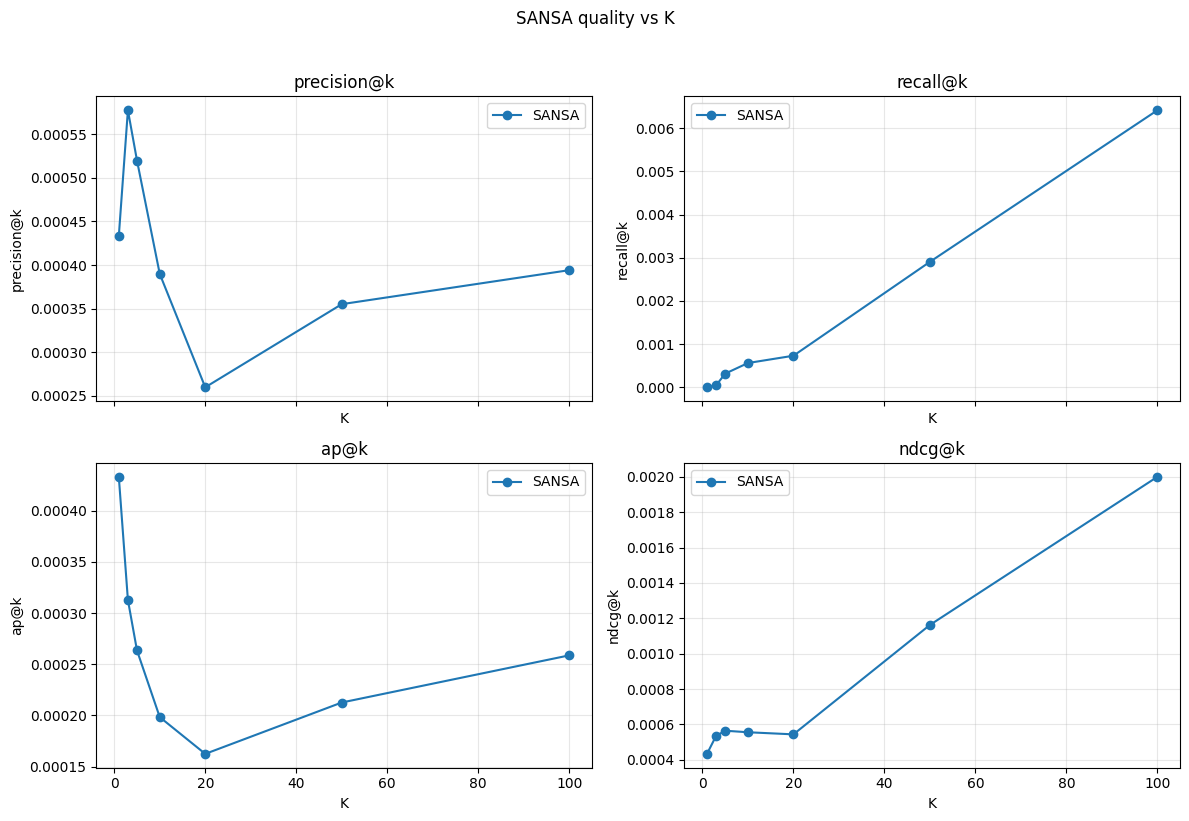

((11916, 11916), 2802807, 0.01973932076397826)

In [34]:
sa = SANSARecommender(l2_lambda=500.0, density_target=0.01)
sa.fit(X)

sc = (X @ sa.W).tocsr()
sc[tr.u.to_numpy(), tr.i.to_numpy()] = -1e9
sc.eliminate_zeros()

ks = np.array([1, 3, 5, 10, 20, 50, 100], dtype=np.int64)
ms = ["precision@k", "recall@k", "ap@k", "ndcg@k"]

rr = {mm: [] for mm in ms}
for k in ks:
    s = {mm: 0.0 for mm in ms}; c0 = 0
    for uu, r_it in rel.items():
        su = sc.getrow(uu).toarray().ravel()
        idx = np.argpartition(-su, k - 1)[:k]
        idx = idx[np.argsort(-su[idx])]
        a = evaluate_recommender(idx, r_it, k)
        for mm in ms:
            s[mm] += a[mm]
        c0 += 1
    for mm in ms:
        rr[mm].append(s[mm] / c0)

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
ax = ax.ravel()
for j, mm in enumerate(ms):
    ax[j].plot(ks, rr[mm], marker="o", label="SANSA")
    ax[j].set_title(mm)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel(mm)
    ax[j].grid(True, alpha=0.3)
    ax[j].legend()
fig.suptitle("SANSA quality vs K", y=1.02)
fig.tight_layout()
plt.show()

sa.W.shape, sa.W.nnz, sa.W.nnz / (sa.W.shape[0] * sa.W.shape[1])


Модель SANSA была обучена с использованием разреженного приближённого разложения Холецкого, что позволило получить масштабируемую версию EASE с разреженной матрицей весов. По результатам экспериментов значения precision@K, recall@K, ap@K и ndcg@K значительно ниже по сравнению с SVD и SLIM на всех K, что указывает на худшее качество рекомендаций на данном датасете. При этом наблюдается монотонный рост recall@K и ndcg@K с увеличением K, однако абсолютные значения метрик остаются низкими.

Полученная матрица весов является разреженной, что подтверждает корректную работу приближённого метода и обеспечивает хорошую масштабируемость по памяти и времени. Таким образом, SANSA выигрывает в вычислительной эффективности и пригодности для очень больших каталогов, но в рамках текущего эксперимента уступает по качеству рекомендаций более простым моделям.

## Conclusion

В ходе экспериментов были реализованы и сравнены модели SVD, SLIM и SANSA по метрикам precision@K, recall@K, ap@K и ndcg@K. Лучшее качество показала модель SVD при размерности латентного пространства 10–20 факторов, обеспечив наибольшие значения recall@K и ndcg@K и устойчивый баланс между точностью и полнотой. При увеличении размерности до 100 наблюдалось переобучение и снижение качества ранжирования.

Модель SLIM продемонстрировала конкурентоспособные результаты и сопоставимое качество с SVD на ряде метрик, при этом обеспечив разреженную и интерпретируемую матрицу item-item коэффициентов. Она оказалась устойчивой и хорошо масштабируемой, особенно за счёт L1-регуляризации, формирующей разреженную структуру весов.

Модель SANSA показала существенно более низкие значения всех метрик на данном датасете, однако подтвердила свою ключевую особенность — получение разреженной матрицы весов при высокой масштабируемости. Таким образом, SVD оказался лучшим по качеству, SLIM — компромиссным вариантом между качеством и интерпретируемостью, а SANSA — наиболее перспективным с точки зрения масштабирования на большие каталоги.